In [1]:
import pandas as pd
df = pd.read_csv('/Users/niraj/Documents/ML/datasets/SC1_CCP.csv')
df.columns

Index(['Sample_no', 'RSN', 'fc_(MPa)', 'fy_(MPa)', 'Ab_(m2)', 'Ac_(m2)',
       'Lx_(m)', 'Ly_(m)', 'Lz_(m)', 'Nx', 'Ny', 'Nz', 'Ap_(m2)', 'AR', 'Kfc',
       'ρ', 'Tm_(sec)', 'PGA_(g)', 'PGV_(cm/sec)', 'PGV/PGA_(sec)',
       'A_RMS_(g)', 'V_RMS_(cm/sec)', 'IA', 'CAV_(cm/sec)', 'Tpred_(sec)',
       'Dsig_(sec)', 'Sa(T1)_(g)', 'T1_(s)', 'T2_(s)', 'T3_(s)',
       'Final_T1 (s)', 'Final_T2 (s)', 'Final_T3 (s)', 'max_base_shear_kN',
       'MIDR_1st_floor', 'MIDR_2nd_floor', 'MIDR_3rd_floor', 'MIDR_4th_floor',
       'MIDR', 'Max_Park_Ang_DI_storey', 'Park_Ang_DI'],
      dtype='object')

In [2]:
df = df.drop(columns=['Sample_no', 'RSN', 'fc_(MPa)', 'fy_(MPa)', 'Ab_(m2)', 'Ac_(m2)', 
                      'Kfc', 'ρ', 'IA', 
                      'T2_(s)', 'T3_(s)',
                      'Final_T1 (s)', 'Final_T2 (s)', 'Final_T3 (s)', 
                      'max_base_shear_kN',
                      'MIDR_1st_floor', 'MIDR_2nd_floor', 'MIDR_3rd_floor', 'MIDR_4th_floor',
                      'Max_Park_Ang_DI_storey', 'Park_Ang_DI'])
df.columns

Index(['Lx_(m)', 'Ly_(m)', 'Lz_(m)', 'Nx', 'Ny', 'Nz', 'Ap_(m2)', 'AR',
       'Tm_(sec)', 'PGA_(g)', 'PGV_(cm/sec)', 'PGV/PGA_(sec)', 'A_RMS_(g)',
       'V_RMS_(cm/sec)', 'CAV_(cm/sec)', 'Tpred_(sec)', 'Dsig_(sec)',
       'Sa(T1)_(g)', 'T1_(s)', 'MIDR'],
      dtype='object')

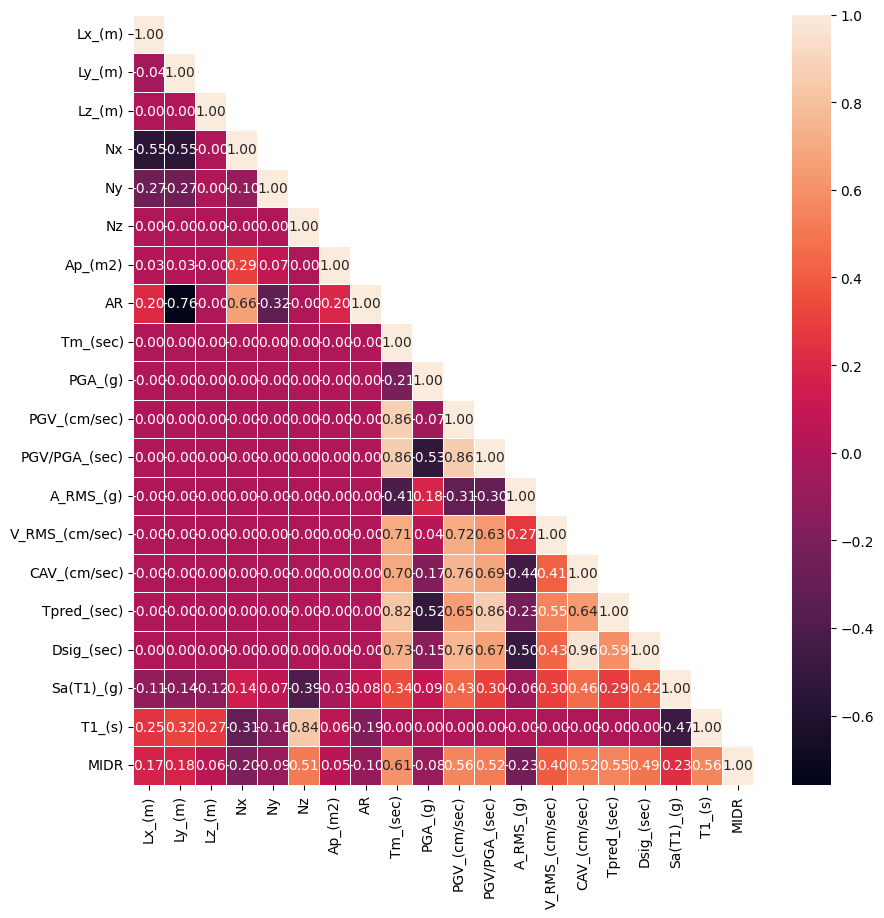

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidth=0.5,
                 fmt=".2f",
                 mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1));

In [4]:
X = df.iloc[:,0:19]
y = df.iloc[:,19]

In [5]:
X

,Lx_(m),Ly_(m),Lz_(m),Nx,Ny,Nz,Ap_(m2),AR,Tm_(sec),PGA_(g),PGV_(cm/sec),PGV/PGA_(sec),A_RMS_(g),V_RMS_(cm/sec),CAV_(cm/sec),Tpred_(sec),Dsig_(sec),Sa(T1)_(g),T1_(s)
0,2.6,2.6,2.75,6,2,2,81.12,3.0,0.3915,0.39736,32.69242,0.08387,0.09111,9.84802,1295.37568,0.14,11.0000,1.01943,0.38416
1,2.6,2.6,2.75,6,2,2,81.12,3.0,1.3218,0.28209,71.28891,0.25761,0.08705,20.24969,3657.26208,2.02,30.7700,0.71053,0.38416
2,2.6,2.6,2.75,6,2,2,81.12,3.0,0.4265,0.42675,27.78368,0.06637,0.06180,5.40371,734.36209,0.12,6.2550,0.90276,0.38416
3,2.6,2.6,2.75,6,2,2,81.12,3.0,0.5113,0.54052,34.53304,0.06513,0.09349,8.53915,635.35772,0.04,5.5425,0.87894,0.38416
4,2.6,2.6,2.75,6,2,2,81.12,3.0,0.6317,0.49082,53.90067,0.11195,0.07601,10.13285,1740.81558,0.52,13.7800,0.96142,0.38416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9571,3.6,4.5,3.20,2,2,4,64.80,0.8,1.2169,0.34798,63.20580,0.18516,0.03675,8.69950,4333.44688,1.26,47.1400,0.79907,1.14028
9572,3.6,4.5,3.20,2,2,4,64.80,0.8,0.8953,0.43745,80.26981,0.18705,0.04725,10.14236,5262.83169,0.96,55.0100,0.89212,1.14028
9573,3.6,4.5,3.20,2,2,4,64.80,0.8,1.4795,0.40191,95.69703,0.24272,0.04227,15.28482,5424.87591,0.82,55.1000,0.79762,1.14028
9574,3.6,4.5,3.20,2,2,4,64.80,0.8,1.0868,0.36297,64.30775,0.18060,0.03359,6.70954,2456.76874,1.26,20.9600,0.80763,1.14028


In [6]:
y

0        1.261
1        1.357
2        1.522
3        1.280
4        1.782
         ...  
9571     9.079
9572     7.133
9573    11.604
9574     7.627
9575     7.092
Name: MIDR, Length: 9576, dtype: float64

In [7]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=10, shuffle=True, random_state=42)

In [8]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
search_rf = BayesSearchCV(
    rf,
    search_spaces={
        'n_estimators': (100, 500),
        'max_depth': (3, 30),
        'min_samples_split': (2, 10)
    },
    n_iter=100,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

In [9]:
print(search_rf)

BayesSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
              estimator=RandomForestRegressor(random_state=42), n_iter=100,
              n_jobs=-1, random_state=42, scoring='neg_root_mean_squared_error',
              search_spaces={'max_depth': (3, 30), 'min_samples_split': (2, 10),
                             'n_estimators': (100, 500)})


In [10]:
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

/Users/niraj/Documents/ML/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/niraj/Documents/ML/.venv/lib/python3.10/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <98D50080-9632-3EA4-B874-146E55453763> /Users/niraj/Documents/ML/.venv/lib/python3.10/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.d

In [ ]:
from xgboost import XGBRegressor

def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 3, 15),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        random_state=42,
        n_jobs=-1
    )
    score = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    return -score.mean()

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)
search_XGB = study_xgb.best_trial

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/niraj/Documents/ML/.venv/lib/python3.10/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <98D50080-9632-3EA4-B874-146E55453763> /Users/niraj/Documents/ML/.venv/lib/python3.10/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.d